# Cookie Cats A/B Test Analysis

**Dataset:** [Cookie Cats A/B Testing](https://www.kaggle.com/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats) â Kaggle

This is real experimental data from **Tactile Entertainment**, the studio behind the mobile puzzle game *Cookie Cats*. In the game, players hit "gates" that force a wait (or an in-app purchase) before continuing. The experiment tested moving the first gate from **level 30** to **level 40**, to see the effect on player retention and engagement. Sample size is ~90,000 players.

- `version = gate_30` → control group (gate at level 30, the original placement)
- `version = gate_40` → treatment group (gate moved to level 40)

---

## Phase 1 Scope

This notebook section covers **data loading, inspection, and quality checks only**. No hypothesis testing on retention and no business conclusions are made here — that is reserved for later sections. The one exception is a **Sample Ratio Mismatch (SRM) check**, which is a data-validity sanity check (confirming randomization worked as intended), not the core experiment analysis.

**Sections in this notebook:**
1. Load & inspect the dataset
2. Column-by-column explanation
3. Data quality checks (shape, dtypes, missing values, duplicates)
4. Experiment group sizes
5. Sample Ratio Mismatch (SRM) check
6. Exploratory summaries of each variable

In [1]:
# Core libraries for data handling, stats, and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display / plotting settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

RANDOM_SEED = 42

## 1. Load & Inspect the Dataset

In [2]:
# Raw data lives untouched in data/raw/ â we read directly from the source file
DATA_PATH = '../data/raw/cookie_cats.csv'

df = pd.read_csv(DATA_PATH)

print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')
df.head(10)

Rows: 90,189  |  Columns: 5


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
5,540,gate_40,187,True,True
6,1066,gate_30,0,False,False
7,1444,gate_40,2,False,False
8,1574,gate_40,108,True,True
9,1587,gate_40,153,True,False


In [3]:
df.tail(5)

,userid,version,sum_gamerounds,retention_1,retention_7
90184,9999441,gate_40,97,True,False
90185,9999479,gate_40,30,False,False
90186,9999710,gate_30,28,True,False
90187,9999768,gate_40,51,True,False
90188,9999861,gate_40,16,False,False


## 2. Column-by-Column Explanation

| Column | Type | Description |
|---|---|---|
| `userid` | integer | Unique identifier for each player. One row per player — this is the experimental unit. |
| `version` | categorical (string) | Which A/B arm the player was assigned to: `gate_30` (control, gate at level 30) or `gate_40` (treatment, gate at level 40). |
| `sum_gamerounds` | integer | Total number of game rounds the player completed in the first 14 days after install. Our engagement / guardrail metric. |
| `retention_1` | boolean | Whether the player came back and played the game 1 day after installing. Primary short-term retention metric. |
| `retention_7` | boolean | Whether the player came back and played the game 7 days after installing. Primary long-term retention metric. |

**Notes on interpretation:**
- `retention_1` and `retention_7` are independent flags — a player can be `retention_7 = True` while `retention_1 = False` (e.g., they skipped day 1 but returned by day 7), so the two columns are not a strict funnel.
- `sum_gamerounds = 0` is a valid value: it means the player installed the game but never actually played a round.

## 3. Data Quality Checks

### 3.1 Shape and Data Types

In [4]:
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n')
df.info()

Shape: 90,189 rows x 5 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


`retention_1` and `retention_7` load as native booleans, `sum_gamerounds` and `userid` as integers, and `version` as an object (string) — these are the expected dtypes for this dataset, so no type coercion is needed.

### 3.2 Missing Values

In [5]:
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().mean() * 100).round(3)
})
missing

,missing_count,missing_pct
userid,0,0.0000
version,0,0.0000
sum_gamerounds,0,0.0000
retention_1,0,0.0000
retention_7,0,0.0000


In [6]:
total_missing = df.isnull().sum().sum()
if total_missing == 0:
    print('No missing values found anywhere in the dataset. No imputation or dropna() needed.')
else:
    print(f'{total_missing} missing values found â see breakdown above.')

No missing values found anywhere in the dataset. No imputation or dropna() needed.


### 3.3 Duplicate User IDs

Each `userid` should appear exactly once, since a row represents one player's full experiment record.

In [7]:
n_rows = len(df)
n_unique_users = df['userid'].nunique()
n_duplicate_userids = df['userid'].duplicated().sum()
n_fully_duplicate_rows = df.duplicated().sum()

print(f'Total rows:                {n_rows:,}')
print(f'Unique userids:            {n_unique_users:,}')
print(f'Duplicated userid rows:    {n_duplicate_userids:,}')
print(f'Fully duplicate rows:      {n_fully_duplicate_rows:,}')

assert n_rows == n_unique_users, 'userid is not unique per row — investigate before proceeding.'
print('\nConfirmed: userid is unique per row. Each player appears exactly once.')

Total rows:                90,189
Unique userids:            90,189
Duplicated userid rows:    0
Fully duplicate rows:      0

Confirmed: userid is unique per row. Each player appears exactly once.


### 3.4 Value Sanity Checks

Quick checks that categorical/boolean columns only contain expected values, and that `sum_gamerounds` has no impossible (negative) values.

In [8]:
print('Unique values in `version`:', df['version'].unique().tolist())
print('Unique values in `retention_1`:', df['retention_1'].unique().tolist())
print('Unique values in `retention_7`:', df['retention_7'].unique().tolist())
print('Min `sum_gamerounds`:', df['sum_gamerounds'].min())
print('Max `sum_gamerounds`:', df['sum_gamerounds'].max())
print('Negative sum_gamerounds count:', (df['sum_gamerounds'] < 0).sum())

Unique values in `version`: ['gate_30', 'gate_40']
Unique values in `retention_1`: [False, True]
Unique values in `retention_7`: [False, True]
Min `sum_gamerounds`: 0
Max `sum_gamerounds`: 49854
Negative sum_gamerounds count: 0


The `version` and retention columns only contain the expected categories, and `sum_gamerounds` has no negative values, which is what we'd expect from a rounds-played counter. The maximum value is flagged and examined further in the outlier check (Section 6.2) — it is far outside the typical range and is noted as a data quality observation, not acted on here.

## 4. Experiment Group Sizes

In [9]:
group_counts = df['version'].value_counts().rename('n_players').to_frame()
group_counts['pct_of_total'] = (group_counts['n_players'] / len(df) * 100).round(2)
group_counts

,n_players,pct_of_total
version,,
gate_40,45489,50.4400
gate_30,44700,49.5600


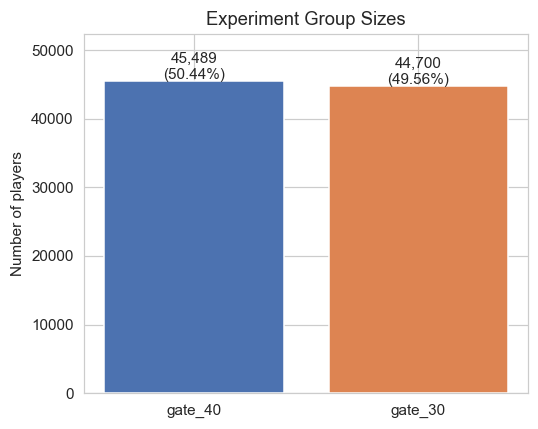

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
colors = ['#4C72B0', '#DD8452']
ax.bar(group_counts.index, group_counts['n_players'], color=colors)
for i, (idx, row) in enumerate(group_counts.iterrows()):
    ax.text(i, row['n_players'] + 300, f"{int(row['n_players']):,}\n({row['pct_of_total']}%)",
            ha='center', fontsize=10)
ax.set_ylabel('Number of players')
ax.set_title('Experiment Group Sizes')
ax.set_ylim(0, group_counts['n_players'].max() * 1.15)
plt.tight_layout()
plt.show()

## 5. Sample Ratio Mismatch (SRM) Check

Before trusting any downstream comparison between groups, we confirm the randomization split is close to the intended ratio (50/50). This is purely a **data-validity check**: if group sizes are meaningfully skewed from what was intended, it signals a bug in the randomization/logging pipeline and would invalidate any later comparison — regardless of what that comparison shows. This is *not* the retention hypothesis test itself, which is deferred to a later phase.

In [11]:
observed = group_counts['n_players'].values
n_total = observed.sum()
expected_ratio = np.array([0.5, 0.5])  # intended 50/50 split
expected = expected_ratio * n_total

chi2_stat, srm_p_value = stats.chisquare(f_obs=observed, f_exp=expected)

print(f'Observed counts : {observed[0]:,} vs {observed[1]:,}')
print(f'Expected counts : {expected[0]:,.1f} vs {expected[1]:,.1f}')
print(f'Observed ratio  : {observed[0] / n_total:.4f} / {observed[1] / n_total:.4f}')
print(f'Chi-square stat : {chi2_stat:.4f}')
print(f'p-value         : {srm_p_value:.4f}')

Observed counts : 45,489 vs 44,700
Expected counts : 45,094.5 vs 45,094.5
Observed ratio  : 0.5044 / 0.4956
Chi-square stat : 6.9024
p-value         : 0.0086


In [12]:
# Standard SRM convention: flag if p < 0.01 (stricter threshold than typical alpha=0.05,
# since SRM checks are a pass/fail gate on data integrity, not the experiment result itself)
SRM_THRESHOLD = 0.01

if srm_p_value < SRM_THRESHOLD:
    print(f'p-value ({srm_p_value:.4f}) < {SRM_THRESHOLD} — SRM DETECTED. Group sizes deviate from the expected split;'
          ' downstream results would need to be treated with caution.')
else:
    print(f'p-value ({srm_p_value:.4f}) >= {SRM_THRESHOLD} — No Sample Ratio Mismatch detected.')
    print('Group sizes are consistent with the intended 50/50 random assignment.')

p-value (0.0086) < 0.01 — SRM DETECTED. Group sizes deviate from the expected split; downstream results would need to be treated with caution.


## 6. Exploratory Summaries of Variables

Descriptive only — no significance testing and no claims about which group performs better. The goal here is purely to understand each variable's distribution before any formal comparison.

### 6.1 `sum_gamerounds` — Overall Distribution

In [13]:
df['sum_gamerounds'].describe(percentiles=[.25, .5, .75, .9, .99])

count   90,189.0000
mean        51.8725
std        195.0509
min          0.0000
25%          5.0000
50%         16.0000
75%         51.0000
90%        134.0000
99%        493.0000
max     49,854.0000
Name: sum_gamerounds, dtype: float64

### 6.2 Outlier Observation

The maximum value identified in Section 3.4 is far beyond the 99th percentile. We look at it directly rather than removing it — the raw data stays untouched at this stage.

In [14]:
top_5_rounds = df.nlargest(5, 'sum_gamerounds')[['userid', 'version', 'sum_gamerounds', 'retention_1', 'retention_7']]
top_5_rounds

,userid,version,sum_gamerounds,retention_1,retention_7
57702,6390605,gate_30,49854,False,True
7912,871500,gate_30,2961,True,True
29417,3271615,gate_40,2640,True,False
43671,4832608,gate_30,2438,True,True
48188,5346171,gate_40,2294,True,True


This single extreme value (far above the next-highest player) is noted here as a data quality observation for later phases to decide how to handle (e.g., capping, exclusion criteria, or robust statistics) — no decision is made in this notebook section.

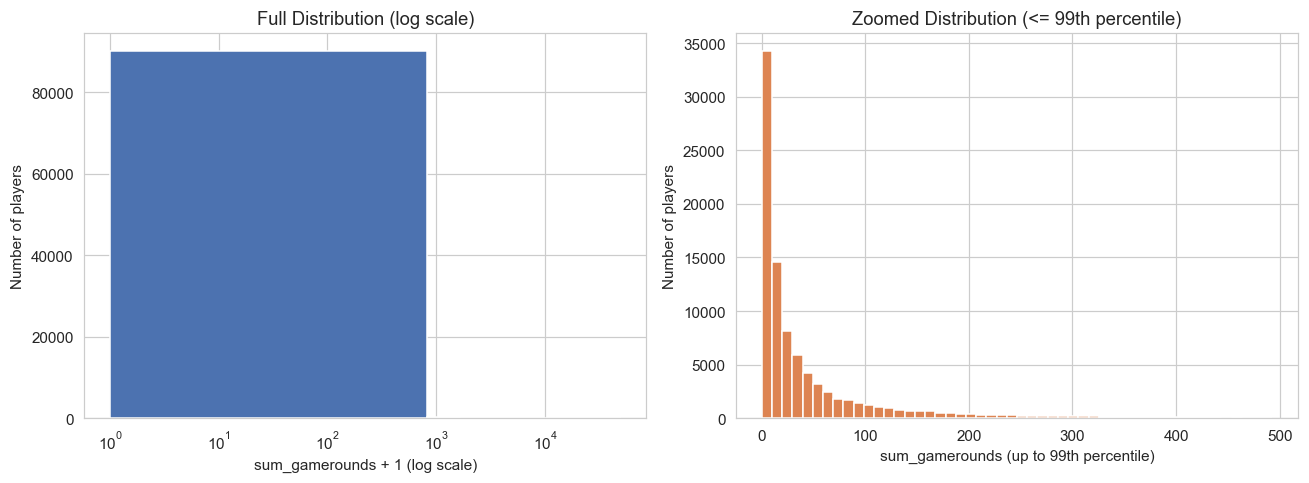

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Full distribution (log scale on x since it's heavily right-skewed)
axes[0].hist(df['sum_gamerounds'] + 1, bins=60, color='#4C72B0', edgecolor='white')
axes[0].set_xscale('log')
axes[0].set_xlabel('sum_gamerounds + 1 (log scale)')
axes[0].set_ylabel('Number of players')
axes[0].set_title('Full Distribution (log scale)')

# Zoomed view, excluding the top 1% so the bulk of the distribution is visible
p99 = df['sum_gamerounds'].quantile(0.99)
zoomed = df.loc[df['sum_gamerounds'] <= p99, 'sum_gamerounds']
axes[1].hist(zoomed, bins=50, color='#DD8452', edgecolor='white')
axes[1].set_xlabel('sum_gamerounds (up to 99th percentile)')
axes[1].set_ylabel('Number of players')
axes[1].set_title('Zoomed Distribution (<= 99th percentile)')

plt.tight_layout()
plt.show()

`sum_gamerounds` is heavily right-skewed: most players play relatively few rounds, a long tail plays a lot, and a small number of players never play a single round at all.

In [16]:
zero_rounds_pct = (df['sum_gamerounds'] == 0).mean() * 100
print(f"Players with sum_gamerounds == 0 (installed but never played a round): {zero_rounds_pct:.2f}%")

Players with sum_gamerounds == 0 (installed but never played a round): 4.43%


### 6.3 `sum_gamerounds` by Group (Descriptive Only)

Side-by-side descriptive statistics per group. This is *not* a guardrail-metric hypothesis test — that comparison, with proper statistical treatment of the skew and the outlier, belongs in a later phase.

In [17]:
df.groupby('version')['sum_gamerounds'].describe(percentiles=[.5, .9, .99]).T

version,gate_30,gate_40
count,"44,700.0000","45,489.0000"
mean,52.4563,51.2988
std,256.7164,103.2944
min,0.0000,0.0000
50%,17.0000,16.0000
90%,135.0000,134.0000
99%,493.0000,492.1200
max,"49,854.0000","2,640.0000"


### 6.4 `retention_1` and `retention_7` — Raw Rates

Raw observed proportions only — no confidence intervals or significance test yet. These are purely descriptive counts to understand the variables before formal analysis.

In [18]:
retention_summary = df.groupby('version')[['retention_1', 'retention_7']].mean().rename(
    columns={'retention_1': 'retention_1_rate', 'retention_7': 'retention_7_rate'}
)
retention_summary['n_players'] = df.groupby('version').size()
retention_summary

,retention_1_rate,retention_7_rate,n_players
version,,,
gate_30,0.4482,0.1902,44700
gate_40,0.4423,0.1820,45489


In [19]:
print('Overall retention_1 rate:', f"{df['retention_1'].mean():.4f}")
print('Overall retention_7 rate:', f"{df['retention_7'].mean():.4f}")
print()
print('retention_1 & retention_7 cross-tab (raw counts):')
pd.crosstab(df['retention_1'], df['retention_7'], margins=True, margins_name='Total')

Overall retention_1 rate: 0.4452
Overall retention_7 rate: 0.1861

retention_1 & retention_7 cross-tab (raw counts):


retention_7,False,True,Total
retention_1,,,
False,46437,3599,50036
True,26971,13182,40153
Total,73408,16781,90189


The cross-tab confirms `retention_1` and `retention_7` are related but not a strict funnel: some players return on day 7 without having returned on day 1.

### 6.5 `version` — Categorical Summary

In [20]:
df['version'].value_counts(normalize=True).rename('proportion').to_frame()

,proportion
version,
gate_40,0.5044
gate_30,0.4956


## Phase 1 Summary

- Dataset loads cleanly: **90,189 rows, 5 columns**, one row per player.
- No missing values in any column.
- `userid` is unique per row — no duplicate players.
- All categorical/boolean columns contain only expected values; `sum_gamerounds` has no negative values.
- Group sizes are close to, but not exactly, a 50/50 split (49.6% gate_30 / 50.4% gate_40). The SRM chi-square check returned **p = 0.0086**, just under the conventional p < 0.01 SRM threshold — a borderline signal worth flagging as a caveat for downstream comparisons, though the absolute imbalance is small (~789 players, <1% of the sample).
- `sum_gamerounds` is heavily right-skewed with one extreme outlier flagged for handling in a later phase.
- `retention_1` and `retention_7` raw rates and the `version` split have been profiled descriptively only — no statistical testing or business conclusions have been drawn.

**Next phase:** formal hypothesis testing on `retention_1` / `retention_7` (proportion z-test / chi-square with effect size and CI), reverse power analysis (MDE), guardrail metric testing on `sum_gamerounds`, segment cuts, and design critique. The borderline SRM result noted above should be revisited when interpreting those results.

# Phase 2: Core Hypothesis Test — Does Moving the Gate Affect Retention?

## Business Question

Tactile Entertainment moved the first progression gate in *Cookie Cats* from **level 30** to **level 40**. The business question this experiment is meant to answer:

> **Does moving the gate later in the game change how many players come back to play?**

Retention is the metric of interest because it is a leading indicator of long-term player base health and, downstream, monetization opportunity. We evaluate this using the two retention flags in the dataset:

- **`retention_1`** — did the player return 1 day after install?
- **`retention_7`** — did the player return 7 days after install?

## Hypotheses

For each retention metric, we test the null hypothesis that gate placement has no effect on the population retention rate, against a two-sided alternative. We do not assume a direction a priori — moving the gate later could plausibly *help* retention (delaying the friction point) or *hurt* it (letting players build more habit/progress before hitting a wall, then losing more of them there):

**Day-1 retention**
- H₀: p(retention_1 | gate_30) = p(retention_1 | gate_40)
- H₁: p(retention_1 | gate_30) ≠ p(retention_1 | gate_40)

**Day-7 retention**
- H₀: p(retention_7 | gate_30) = p(retention_7 | gate_40)
- H₁: p(retention_7 | gate_30) ≠ p(retention_7 | gate_40)

Both tests are run at **α = 0.05**, two-sided.

## Carrying Forward the Phase 1 Caveat

Phase 1's SRM check found a borderline imbalance in group sizes (χ² p = 0.0086, just under the 0.01 SRM threshold). This does not invalidate the tests below, but it means any statistically significant result here should be interpreted with some caution about whether the imbalance reflects a subtle issue in random assignment. We return to this point in the interpretation section.

In [21]:
# Statistical tools for two-sample proportion testing
from statsmodels.stats.proportion import proportions_ztest, proportion_confint, confint_proportions_2indep
from scipy.stats import chi2_contingency

CONTROL = 'gate_30'
TREATMENT = 'gate_40'
ALPHA = 0.05

## 2.1 Day-1 Retention (`retention_1`)

**Methodology:** for each metric we compute, using a two-sided two-proportion z-test (equivalent to an uncorrected chi-square test of independence on a 2x2 table):

- Retention rate per group
- Absolute difference (treatment − control) and relative difference (% change vs. control)
- 95% confidence interval for the difference in proportions, using the **Newcombe score interval** (more reliable than the Wald interval for proportions, especially near 0 or 1)
- z-statistic and two-sided p-value
- **Cohen's h**, the standard effect size measure for the difference between two proportions

A chi-square test is run alongside the z-test as a cross-check — for a 2×2 table without continuity correction, χ² = z², so the two should agree.

In [22]:
def two_proportion_test(data, metric, control=CONTROL, treatment=TREATMENT, alpha=ALPHA):
    """Two-proportion z-test + 95% CI (Newcombe) + effect size for a binary outcome, control vs. treatment."""
    successes = data.groupby('version')[metric].sum()
    nobs = data.groupby('version').size()

    count = np.array([successes[control], successes[treatment]])
    n = np.array([nobs[control], nobs[treatment]])

    p_control = count[0] / n[0]
    p_treatment = count[1] / n[1]

    z_stat, p_value = proportions_ztest(count, n, alternative='two-sided')

    # Newcombe score interval for the difference (treatment - control)
    ci_low, ci_high = confint_proportions_2indep(
        count[1], n[1], count[0], n[0], method='newcomb', compare='diff', alpha=alpha
    )

    abs_diff = p_treatment - p_control
    rel_diff_pct = (abs_diff / p_control) * 100

    # Cohen's h: standard effect size for the difference between two proportions
    cohens_h = 2 * np.arcsin(np.sqrt(p_treatment)) - 2 * np.arcsin(np.sqrt(p_control))

    # Chi-square cross-check (uncorrected, 2x2 table) -- chi2_stat should equal z_stat**2
    contingency = np.array([
        [count[0], n[0] - count[0]],
        [count[1], n[1] - count[1]],
    ])
    chi2_stat, chi2_p, _, _ = chi2_contingency(contingency, correction=False)

    return {
        'metric': metric,
        'n_control': n[0], 'n_treatment': n[1],
        'rate_control': p_control, 'rate_treatment': p_treatment,
        'abs_diff': abs_diff, 'rel_diff_pct': rel_diff_pct,
        'ci_diff_low': ci_low, 'ci_diff_high': ci_high,
        'z_stat': z_stat, 'p_value': p_value,
        'cohens_h': cohens_h,
        'chi2_stat': chi2_stat, 'chi2_p': chi2_p,
    }


def print_result(res):
    print(f"Metric: {res['metric']}")
    print(f"  n ({CONTROL} / {TREATMENT}):        {res['n_control']:,} / {res['n_treatment']:,}")
    print(f"  Retention rate {CONTROL}:      {res['rate_control']:.4f}")
    print(f"  Retention rate {TREATMENT}:      {res['rate_treatment']:.4f}")
    print(f"  Absolute difference (treatment - control): {res['abs_diff']:+.4f}")
    print(f"  Relative difference vs. control:           {res['rel_diff_pct']:+.2f}%")
    print(f"  95% CI for difference (Newcombe):          [{res['ci_diff_low']:+.4f}, {res['ci_diff_high']:+.4f}]")
    print(f"  z-statistic: {res['z_stat']:.4f}   p-value: {res['p_value']:.6f}")
    print(f"  Chi-square:  {res['chi2_stat']:.4f}   p-value: {res['chi2_p']:.6f}  (cross-check, should equal z^2)")
    print(f"  Cohen's h (effect size): {res['cohens_h']:.4f}")


result_r1 = two_proportion_test(df, 'retention_1')
print_result(result_r1)

Metric: retention_1


  n (gate_30 / gate_40):        44,700 / 45,489
  Retention rate gate_30:      0.4482
  Retention rate gate_40:      0.4423
  Absolute difference (treatment - control): -0.0059
  Relative difference vs. control:           -1.32%
  95% CI for difference (Newcombe):          [-0.0124, +0.0006]
  z-statistic: 1.7841   p-value: 0.074410
  Chi-square:  3.1830   p-value: 0.074410  (cross-check, should equal z^2)
  Cohen's h (effect size): -0.0119


## 2.2 Day-7 Retention (`retention_7`)

In [23]:
result_r7 = two_proportion_test(df, 'retention_7')
print_result(result_r7)

Metric: retention_7
  n (gate_30 / gate_40):        44,700 / 45,489
  Retention rate gate_30:      0.1902
  Retention rate gate_40:      0.1820
  Absolute difference (treatment - control): -0.0082
  Relative difference vs. control:           -4.31%
  95% CI for difference (Newcombe):          [-0.0133, -0.0031]
  z-statistic: 3.1644   p-value: 0.001554
  Chi-square:  10.0132   p-value: 0.001554  (cross-check, should equal z^2)
  Cohen's h (effect size): -0.0211


## 2.3 Summary Table — Rates, Differences, CI, p-values, Effect Sizes

A single table combining both metrics for easy comparison and reporting.

In [24]:
summary_rows = []
for res in (result_r1, result_r7):
    summary_rows.append({
        'metric': res['metric'],
        f'rate_{CONTROL}': res['rate_control'],
        f'rate_{TREATMENT}': res['rate_treatment'],
        'abs_diff': res['abs_diff'],
        'rel_diff_pct': res['rel_diff_pct'],
        'ci_95_low': res['ci_diff_low'],
        'ci_95_high': res['ci_diff_high'],
        'z_stat': res['z_stat'],
        'p_value': res['p_value'],
        'cohens_h': res['cohens_h'],
        'significant_at_0.05': res['p_value'] < ALPHA,
    })

summary_df = pd.DataFrame(summary_rows).set_index('metric')
summary_df

,rate_gate_30,rate_gate_40,abs_diff,rel_diff_pct,ci_95_low,ci_95_high,z_stat,p_value,cohens_h,significant_at_0.05
metric,,,,,,,,,,
retention_1,0.4482,0.4423,-0.0059,-1.3176,-0.0124,0.0006,1.7841,0.0744,-0.0119,False
retention_7,0.1902,0.1820,-0.0082,-4.3119,-0.0133,-0.0031,3.1644,0.0016,-0.0211,True


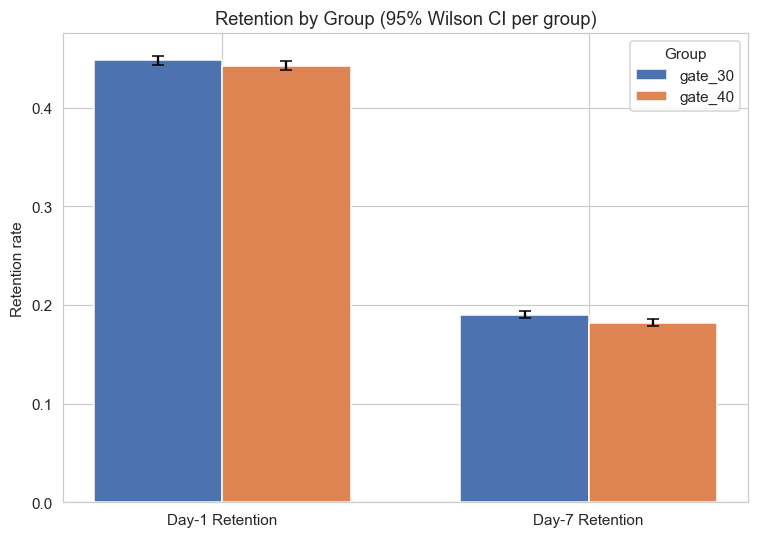

In [25]:
metrics = ['retention_1', 'retention_7']
fig, ax = plt.subplots(figsize=(7, 5))

x = np.arange(len(metrics))
width = 0.35

for i, (version, color) in enumerate(zip([CONTROL, TREATMENT], ['#4C72B0', '#DD8452'])):
    rates, err_low, err_high = [], [], []
    for metric in metrics:
        successes = df.loc[df['version'] == version, metric].sum()
        n = (df['version'] == version).sum()
        rate = successes / n
        lo, hi = proportion_confint(successes, n, alpha=ALPHA, method='wilson')
        rates.append(rate)
        err_low.append(rate - lo)
        err_high.append(hi - rate)
    ax.bar(x + (i - 0.5) * width, rates, width, yerr=[err_low, err_high], capsize=4,
           label=version, color=color)

ax.set_xticks(x)
ax.set_xticklabels(['Day-1 Retention', 'Day-7 Retention'])
ax.set_ylabel('Retention rate')
ax.set_title('Retention by Group (95% Wilson CI per group)')
ax.legend(title='Group')
plt.tight_layout()
plt.show()

## 2.4 Assumptions

The two-proportion z-test (and its chi-square equivalent) relies on the following assumptions. We state each one and whether it holds here:

1. **Independence of observations.** Each row is one player, and each player appears exactly once (confirmed in Phase 1) and belongs to exactly one arm — satisfied.
2. **Independent random assignment to groups.** This is the core assumption behind causal interpretation of the comparison. Phase 1's SRM check found a *borderline* imbalance (χ² p = 0.0086, just under the 0.01 flag threshold) — not strong evidence of a broken randomizer, but not a clean pass either. We treat this as a caveat on causal interpretation rather than a reason to discard the test.
3. **Binary outcome per unit.** `retention_1` and `retention_7` are boolean flags per player — satisfied by construction.
4. **Sample size large enough for the normal approximation to the binomial** (rule of thumb: at least ~5 successes and ~5 failures per group). Checked explicitly below — with tens of thousands of players per arm, this is satisfied with enormous headroom for both metrics.
5. **No multiple-testing correction applied.** We run two tests (Day-1, Day-7) at α = 0.05 each. With only two pre-specified, closely related metrics, we report each p-value as-is rather than applying a correction (e.g., Bonferroni) — but this is worth flagging since running many metrics without correction would inflate the false-positive rate.

In [26]:
print('Normal-approximation validity check (need count and (n - count) >= 5 in every cell):\n')
for metric in ['retention_1', 'retention_7']:
    for version in [CONTROL, TREATMENT]:
        successes = df.loc[df['version'] == version, metric].sum()
        n = (df['version'] == version).sum()
        fails = n - successes
        print(f'{metric:12s} | {version:8s} -> successes={successes:>6,}  failures={fails:>6,}  (min={min(successes, fails):,})')

Normal-approximation validity check (need count and (n - count) >= 5 in every cell):

retention_1  | gate_30  -> successes=20,034  failures=24,666  (min=20,034)
retention_1  | gate_40  -> successes=20,119  failures=25,370  (min=20,119)
retention_7  | gate_30  -> successes= 8,502  failures=36,198  (min=8,502)
retention_7  | gate_40  -> successes= 8,279  failures=37,210  (min=8,279)


## 2.5 Business Interpretation

**Day-1 retention: no statistically significant difference.**
Retention drops from 44.82% (gate_30) to 44.23% (gate_40) — a −0.59 percentage-point (−1.32% relative) difference. The 95% CI for the difference is **[−1.24pp, +0.06pp]**, which includes zero, and the p-value (0.0744) is above the α = 0.05 threshold. We cannot reject H₀ for Day-1 retention. The effect size (Cohen's h = −0.012) is negligible regardless.

**Day-7 retention: statistically significant decrease.**
Retention drops from 19.02% (gate_30) to 18.20% (gate_40) — a −0.82 percentage-point (−4.31% relative) difference. The 95% CI, **[−1.33pp, −0.31pp]**, excludes zero, and p = 0.0016 is well below α = 0.05. We reject H₀ for Day-7 retention: moving the gate to level 40 is associated with lower 7-day retention in this experiment.

**On effect size vs. statistical significance.** Cohen's h for Day-7 (−0.021) is still very small by conventional benchmarks (small ≈ 0.2) — it reaches statistical significance only because the sample size (~90K) gives the test enough power to detect even a small, real difference precisely. Statistically significant here does not mean *large*; both results point to a small effect, and Day-7's is the one we're confident isn't just noise.

**Business read.** Within this experiment, delaying the first gate from level 30 to level 40 did not measurably move Day-1 behavior, but it corresponds to a small, real decline in Day-7 retention (~4% relative drop). Directionally, this argues against pushing the gate later purely on retention grounds — the extra progression before the friction point does not appear to build enough habit/investment to offset players lost at the new gate, at least not by day 7.

**Why we stop short of a causal, generalizable claim:**
- **Phase 1 SRM caveat.** The borderline group-size imbalance (p = 0.0086) doesn't overturn this result, but it's a reason for mild caution rather than full confidence that assignment was clean — worth a mention if this number is used to justify a decision.
- **Single experiment, single game, one time window.** This tells us what happened for Cookie Cats players during this specific test, not that gate placement generally hurts retention in mobile games.
- **Retention isn't the whole picture.** We haven't yet looked at the guardrail metric (`sum_gamerounds`) or whether the effect is concentrated in a particular engagement segment — both come in later phases and could change the practical takeaway (e.g., if gate_40 increases rounds played per session, the retention cost might be an acceptable trade-off).
- **No mechanism established.** The test tells us *that* retention differs, not *why* — we have not verified this is driven by the gate itself rather than some other correlated change.

## Phase 2 Summary

| Metric | gate_30 | gate_40 | Abs. diff | Rel. diff | 95% CI | p-value | Cohen's h | Significant (α=0.05)? |
|---|---|---|---|---|---|---|---|---|
| Day-1 retention | 44.82% | 44.23% | −0.59pp | −1.32% | [−1.24pp, +0.06pp] | 0.0744 | −0.012 | No |
| Day-7 retention | 19.02% | 18.20% | −0.82pp | −4.31% | [−1.33pp, −0.31pp] | 0.0016 | −0.021 | **Yes** |

- Moving the gate from level 30 to level 40 shows **no significant effect on Day-1 retention** but a **statistically significant, small decrease in Day-7 retention**.
- Both effect sizes are small in absolute terms (Cohen's h well under the "small" benchmark of 0.2) — statistical significance on Day-7 comes from the large sample, not a large effect.
- The z-test and chi-square cross-checks agreed exactly on both metrics, confirming the implementation.
- Normal-approximation assumptions are comfortably satisfied (thousands of successes/failures in every cell).
- The Phase 1 SRM caveat (borderline p = 0.0086) is carried forward as a caution on causal interpretation, not a reason to discard these results.
- No claim is made about guardrail engagement, segment-level effects, or generalization beyond this experiment — those are addressed in later phases.

**Next phase:** reverse power analysis (minimum detectable effect at 80% power, and whether the Day-1 "no effect" result might just be underpowered), guardrail metric check on `sum_gamerounds`, retention effect by engagement segment, and design critique.